In [1]:
# DAY 35 - COMBINING CUSTOMER INTELLIGENCE MODULES
# Sprint Review & System Integration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Day 35 libraries imported successfully!")

Day 35 libraries imported successfully!


In [2]:
# DAY 35 - COMBINING CUSTOMER INTELLIGENCE MODULES
# Sprint Review & System Integration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Day 35 libraries imported successfully!")

Day 35 libraries imported successfully!


In [3]:
# Load outputs from previous customer intelligence modules

segment_df = pd.read_csv("../Day30/customer_segments_final.csv")
persona_df = pd.read_csv("../Day31/customer_persona_summary.csv")
recommendation_df = pd.read_csv("../Day32/recommendation_output.csv")
anomaly_df = pd.read_csv("../Day33/customer_anomaly_results.csv")

print("Previous customer intelligence modules loaded successfully!")

print("\nSegmentation:", segment_df.shape)
print("Persona:", persona_df.shape)
print("Recommendations:", recommendation_df.shape)
print("Anomaly detection:", anomaly_df.shape)

Previous customer intelligence modules loaded successfully!

Segmentation: (795, 9)
Persona: (2, 8)
Recommendations: (5, 2)
Anomaly detection: (795, 9)


In [4]:
# Check the columns from all integrated modules

print("SEGMENTATION COLUMNS:")
print(segment_df.columns.tolist())

print("\nPERSONA COLUMNS:")
print(persona_df.columns.tolist())

print("\nRECOMMENDATION COLUMNS:")
print(recommendation_df.columns.tolist())

print("\nANOMALY COLUMNS:")
print(anomaly_df.columns.tolist())

SEGMENTATION COLUMNS:
['customer_name', 'total_sales', 'total_quantity', 'total_profit', 'average_discount', 'average_shipping_days', 'number_of_orders', 'cluster', 'segment_name']

PERSONA COLUMNS:
['segment_name', 'Average Sales', 'Average Quantity', 'Average Profit', 'Average Discount', 'Average Shipping Days', 'Average Orders', 'Customer Count']

RECOMMENDATION COLUMNS:
['product_name', 'recommendation_score']

ANOMALY COLUMNS:
['customer_name', 'total_sales', 'total_quantity', 'total_profit', 'average_discount', 'average_shipping_days', 'number_of_orders', 'anomaly', 'behavior_status']


In [5]:
# Integrate customer segmentation and anomaly detection

customer_intelligence = segment_df.merge(
    anomaly_df[
        [
            "customer_name",
            "anomaly",
            "behavior_status"
        ]
    ],
    on="customer_name",
    how="left"
)

print("Customer intelligence table created successfully!")

print("Shape:", customer_intelligence.shape)

print("\nColumns:")
print(customer_intelligence.columns.tolist())

display(customer_intelligence.head())

Customer intelligence table created successfully!
Shape: (795, 11)

Columns:
['customer_name', 'total_sales', 'total_quantity', 'total_profit', 'average_discount', 'average_shipping_days', 'number_of_orders', 'cluster', 'segment_name', 'anomaly', 'behavior_status']


,customer_name,total_sales,total_quantity,total_profit,average_discount,average_shipping_days,number_of_orders,cluster,segment_name,anomaly,behavior_status
0,Aaron Bergman,24646.0,301,4683.20800,0.110112,3.707865,89,0,High-Value Customers,1,Normal
1,Aaron Hawkins,20759.0,231,2450.92904,0.160929,3.464286,56,0,High-Value Customers,1,Normal
2,Aaron Smayling,14207.0,211,369.16180,0.167667,4.433333,60,1,Regular Customers,1,Normal
3,Adam Bellavance,20189.0,262,4979.97690,0.131765,3.514706,68,0,High-Value Customers,1,Normal
4,Adam Hart,21720.0,293,1902.03342,0.093238,3.654762,84,0,High-Value Customers,1,Normal


In [7]:
# DAY 35 - ADD CUSTOMER ACTIVITY RISK
# Self-contained code

# Load the main cleaned sales dataset
sales_df = pd.read_csv("../cleaned_dataset.csv")

# Convert order date to datetime
sales_df["order_date"] = pd.to_datetime(sales_df["order_date"])

# Create customer activity information
customer_activity = (
    sales_df.groupby("customer_name")
    .agg(
        last_order_date=("order_date", "max"),
        number_of_orders=("order_id", "nunique")
    )
    .reset_index()
)

# Find the latest date in the dataset
latest_date = sales_df["order_date"].max()

# Calculate days since the customer's last order
customer_activity["days_since_last_order"] = (
    latest_date - customer_activity["last_order_date"]
).dt.days

# Create activity-risk categories
customer_activity["activity_risk"] = pd.cut(
    customer_activity["days_since_last_order"],
    bins=[-1, 30, 90, float("inf")],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Check whether the integrated customer table already exists
if "customer_intelligence" not in globals():

    # Load segmentation data
    segment_df = pd.read_csv(
        "../Day30/customer_segments_final.csv"
    )

    # Load anomaly data
    anomaly_df = pd.read_csv(
        "../Day33/customer_anomaly_results.csv"
    )

    # Combine segmentation + anomaly information
    customer_intelligence = segment_df.merge(
        anomaly_df[
            [
                "customer_name",
                "anomaly",
                "behavior_status"
            ]
        ],
        on="customer_name",
        how="left"
    )

# Add activity information
customer_intelligence = customer_intelligence.merge(
    customer_activity[
        [
            "customer_name",
            "last_order_date",
            "days_since_last_order",
            "activity_risk"
        ]
    ],
    on="customer_name",
    how="left"
)

print("Customer activity risk integrated successfully!")

print("\nIntegrated customer table shape:")
print(customer_intelligence.shape)

print("\nIntegrated columns:")
print(customer_intelligence.columns.tolist())

print("\nSample customer intelligence data:")

display(
    customer_intelligence[
        [
            "customer_name",
            "segment_name",
            "behavior_status",
            "days_since_last_order",
            "activity_risk"
        ]
    ].head()
)

Customer activity risk integrated successfully!

Integrated customer table shape:
(795, 14)

Integrated columns:
['customer_name', 'total_sales', 'total_quantity', 'total_profit', 'average_discount', 'average_shipping_days', 'number_of_orders', 'cluster', 'segment_name', 'anomaly', 'behavior_status', 'last_order_date', 'days_since_last_order', 'activity_risk']

Sample customer intelligence data:


,customer_name,segment_name,behavior_status,days_since_last_order,activity_risk
0,Aaron Bergman,High-Value Customers,Normal,16,Low Risk
1,Aaron Hawkins,High-Value Customers,Normal,12,Low Risk
2,Aaron Smayling,Regular Customers,Normal,23,Low Risk
3,Adam Bellavance,High-Value Customers,Normal,35,Medium Risk
4,Adam Hart,High-Value Customers,Normal,2,Low Risk


In [8]:
# Create unified customer intelligence summary

unified_summary = customer_intelligence[
    [
        "customer_name",
        "segment_name",
        "total_sales",
        "total_profit",
        "number_of_orders",
        "behavior_status",
        "days_since_last_order",
        "activity_risk"
    ]
].copy()

print("Unified customer intelligence summary created successfully!")

print("Summary shape:", unified_summary.shape)

display(unified_summary.head(10))

Unified customer intelligence summary created successfully!
Summary shape: (795, 8)


,customer_name,segment_name,total_sales,total_profit,number_of_orders,behavior_status,days_since_last_order,activity_risk
0,Aaron Bergman,High-Value Customers,24646.0,4683.20800,89,Normal,16,Low Risk
1,Aaron Hawkins,High-Value Customers,20759.0,2450.92904,56,Normal,12,Low Risk
2,Aaron Smayling,Regular Customers,14207.0,369.16180,60,Normal,23,Low Risk
3,Adam Bellavance,High-Value Customers,20189.0,4979.97690,68,Normal,35,Medium Risk
4,Adam Hart,High-Value Customers,21720.0,1902.03342,84,Normal,2,Low Risk
5,Adam Shillingsburg,High-Value Customers,15445.0,1421.27412,71,Normal,15,Low Risk
6,Adrian Barton,High-Value Customers,25125.0,6417.28450,77,Normal,27,Low Risk
7,Adrian Hane,Regular Customers,11406.0,2081.37928,54,Normal,21,Low Risk
8,Adrian Shami,Regular Customers,11287.0,1564.49380,44,Normal,41,Medium Risk
9,Aimee Bixby,Regular Customers,16205.0,2926.35430,55,Normal,35,Medium Risk


In [9]:
# Prepare the recommendation module

recommendation_summary = recommendation_df.copy()

recommendation_summary = recommendation_summary.sort_values(
    "recommendation_score",
    ascending=False
).reset_index(drop=True)

print("Recommendation module integrated successfully!")

print("Number of recommended products:", len(recommendation_summary))

display(recommendation_summary.head(10))

Recommendation module integrated successfully!
Number of recommended products: 5


,product_name,recommendation_score
0,"Motorola Office Telephone, Cordless",1.909797
1,"Okidata Inkjet, White",1.500555
2,"Stanley Pencil Sharpener, Water Color",1.227952
3,"Tenex Clock, Duo Pack",1.227727
4,"Hewlett Wireless Fax, High-Speed",1.118824


In [10]:
# Calculate unified analytics KPIs

total_customers = unified_summary["customer_name"].nunique()

high_value_customers = (
    unified_summary["segment_name"]
    .eq("High-Value Customers")
    .sum()
)

anomalous_customers = (
    unified_summary["behavior_status"]
    .eq("Anomalous")
    .sum()
)

high_risk_customers = (
    unified_summary["activity_risk"]
    .eq("High Risk")
    .sum()
)

total_sales = unified_summary["total_sales"].sum()
total_profit = unified_summary["total_profit"].sum()

print("UNIFIED ANALYTICS KPIs")
print("=" * 45)

print("Total Customers:", total_customers)
print("High-Value Customers:", high_value_customers)
print("Anomalous Customers:", anomalous_customers)
print("High Activity-Risk Customers:", high_risk_customers)
print("Total Customer Sales:", round(total_sales, 2))
print("Total Customer Profit:", round(total_profit, 2))

print("\nUnified KPI calculation completed successfully!")

UNIFIED ANALYTICS KPIs
Total Customers: 795
High-Value Customers: 338
Anomalous Customers: 40
High Activity-Risk Customers: 22
Total Customer Sales: 12642905.0
Total Customer Profit: 1469034.82

Unified KPI calculation completed successfully!


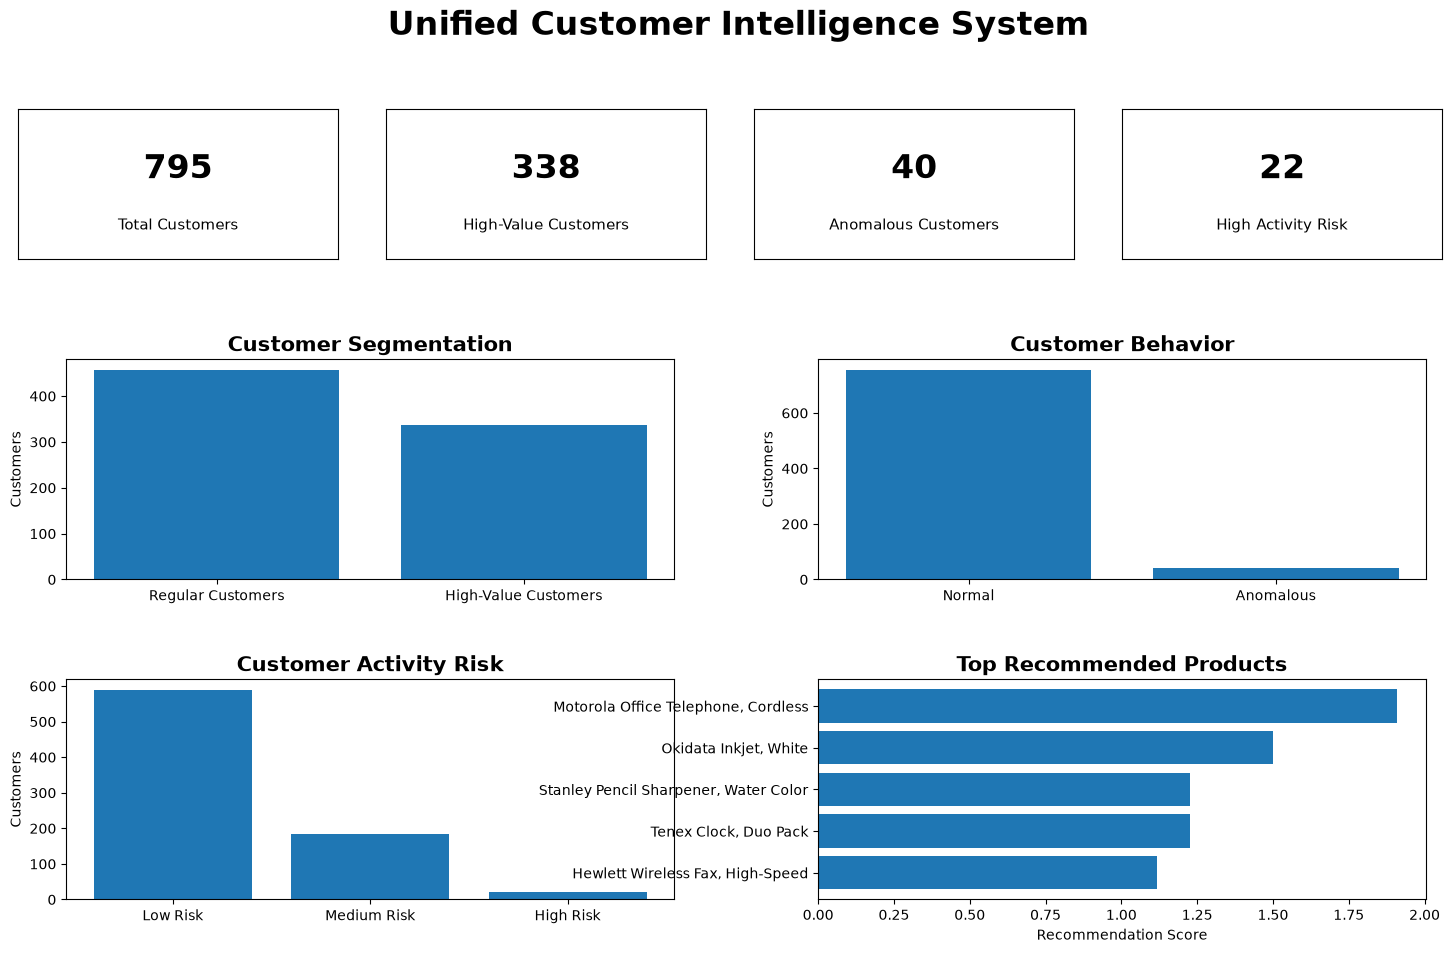

Unified customer analytics dashboard created successfully!
Saved as: unified_customer_analytics_dashboard.png


In [11]:
# Create unified customer analytics dashboard

fig = plt.figure(figsize=(16, 10))

fig.suptitle(
    "Unified Customer Intelligence System",
    fontsize=24,
    fontweight="bold",
    y=0.97
)

# --------------------------------
# KPI 1 - Total Customers
# --------------------------------
ax1 = fig.add_axes([0.05, 0.72, 0.20, 0.15])

ax1.text(
    0.5, 0.6,
    f"{total_customers:,}",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold"
)

ax1.text(
    0.5, 0.2,
    "Total Customers",
    ha="center",
    fontsize=11
)

ax1.set_xticks([])
ax1.set_yticks([])

# --------------------------------
# KPI 2 - High Value Customers
# --------------------------------
ax2 = fig.add_axes([0.28, 0.72, 0.20, 0.15])

ax2.text(
    0.5, 0.6,
    f"{high_value_customers:,}",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold"
)

ax2.text(
    0.5, 0.2,
    "High-Value Customers",
    ha="center",
    fontsize=11
)

ax2.set_xticks([])
ax2.set_yticks([])

# --------------------------------
# KPI 3 - Anomalous Customers
# --------------------------------
ax3 = fig.add_axes([0.51, 0.72, 0.20, 0.15])

ax3.text(
    0.5, 0.6,
    f"{anomalous_customers:,}",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold"
)

ax3.text(
    0.5, 0.2,
    "Anomalous Customers",
    ha="center",
    fontsize=11
)

ax3.set_xticks([])
ax3.set_yticks([])

# --------------------------------
# KPI 4 - High Risk Customers
# --------------------------------
ax4 = fig.add_axes([0.74, 0.72, 0.20, 0.15])

ax4.text(
    0.5, 0.6,
    f"{high_risk_customers:,}",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold"
)

ax4.text(
    0.5, 0.2,
    "High Activity Risk",
    ha="center",
    fontsize=11
)

ax4.set_xticks([])
ax4.set_yticks([])

# --------------------------------
# Segment chart
# --------------------------------
ax5 = fig.add_axes([0.08, 0.40, 0.38, 0.22])

segment_counts = (
    unified_summary["segment_name"]
    .value_counts()
)

ax5.bar(
    segment_counts.index,
    segment_counts.values
)

ax5.set_title(
    "Customer Segmentation",
    fontsize=15,
    fontweight="bold"
)

ax5.set_ylabel("Customers")

# --------------------------------
# Behavior chart
# --------------------------------
ax6 = fig.add_axes([0.55, 0.40, 0.38, 0.22])

behavior_counts = (
    unified_summary["behavior_status"]
    .value_counts()
)

ax6.bar(
    behavior_counts.index,
    behavior_counts.values
)

ax6.set_title(
    "Customer Behavior",
    fontsize=15,
    fontweight="bold"
)

ax6.set_ylabel("Customers")

# --------------------------------
# Activity Risk chart
# --------------------------------
ax7 = fig.add_axes([0.08, 0.08, 0.38, 0.22])

risk_counts = (
    unified_summary["activity_risk"]
    .value_counts()
    .reindex(
        ["Low Risk", "Medium Risk", "High Risk"]
    )
    .fillna(0)
)

ax7.bar(
    risk_counts.index,
    risk_counts.values
)

ax7.set_title(
    "Customer Activity Risk",
    fontsize=15,
    fontweight="bold"
)

ax7.set_ylabel("Customers")

# --------------------------------
# Recommendation chart
# --------------------------------
ax8 = fig.add_axes([0.55, 0.08, 0.38, 0.22])

top_recommendations = recommendation_summary.head(5)

ax8.barh(
    top_recommendations["product_name"],
    top_recommendations["recommendation_score"]
)

ax8.set_title(
    "Top Recommended Products",
    fontsize=15,
    fontweight="bold"
)

ax8.set_xlabel("Recommendation Score")

ax8.invert_yaxis()

# --------------------------------
# Save dashboard
# --------------------------------
plt.savefig(
    "unified_customer_analytics_dashboard.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Unified customer analytics dashboard created successfully!")
print("Saved as: unified_customer_analytics_dashboard.png")

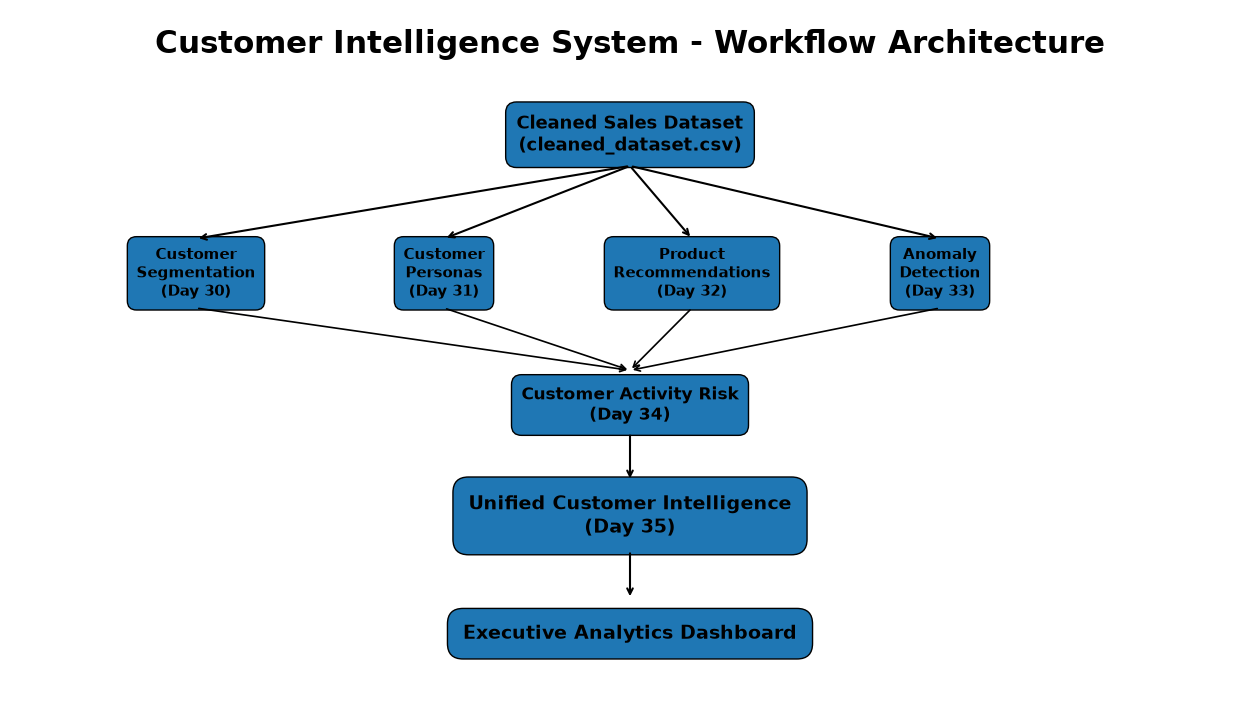

Workflow architecture diagram created successfully!
Saved as: workflow_architecture.png


In [12]:
# DAY 35 - WORKFLOW ARCHITECTURE DIAGRAM

fig, ax = plt.subplots(figsize=(16, 9))

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

# Title
ax.text(
    5, 9.5,
    "Customer Intelligence System - Workflow Architecture",
    ha="center",
    va="center",
    fontsize=22,
    fontweight="bold"
)

# Main dataset
ax.text(
    5, 8.2,
    "Cleaned Sales Dataset\n(cleaned_dataset.csv)",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.6")
)

# Module boxes
modules = [
    (1.5, 6.2, "Customer\nSegmentation\n(Day 30)"),
    (3.5, 6.2, "Customer\nPersonas\n(Day 31)"),
    (5.5, 6.2, "Product\nRecommendations\n(Day 32)"),
    (7.5, 6.2, "Anomaly\nDetection\n(Day 33)")
]

for x, y, text in modules:
    ax.text(
        x, y,
        text,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.6")
    )

# Activity risk
ax.text(
    5, 4.3,
    "Customer Activity Risk\n(Day 34)",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.6")
)

# Unified intelligence
ax.text(
    5, 2.7,
    "Unified Customer Intelligence\n(Day 35)",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.8")
)

# Executive dashboard
ax.text(
    5, 1.0,
    "Executive Analytics Dashboard",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.8")
)

# Connections from dataset to modules
for x, y, _ in modules:
    ax.annotate(
        "",
        xy=(x, y + 0.5),
        xytext=(5, 7.75),
        arrowprops=dict(arrowstyle="->", linewidth=1.5)
    )

# Modules to activity risk
for x, y, _ in modules:
    ax.annotate(
        "",
        xy=(5, 4.8),
        xytext=(x, 5.7),
        arrowprops=dict(arrowstyle="->", linewidth=1.2)
    )

# Activity risk to unified system
ax.annotate(
    "",
    xy=(5, 3.2),
    xytext=(5, 3.9),
    arrowprops=dict(arrowstyle="->", linewidth=1.5)
)

# Unified system to dashboard
ax.annotate(
    "",
    xy=(5, 1.5),
    xytext=(5, 2.2),
    arrowprops=dict(arrowstyle="->", linewidth=1.5)
)

plt.savefig(
    "workflow_architecture.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Workflow architecture diagram created successfully!")
print("Saved as: workflow_architecture.png")

# Week 5 Sprint Reflection

## What I Built

During Week 5, I developed multiple customer intelligence modules and integrated them into one unified analytics workflow.

The modules included:

- Customer Segmentation
- Customer Personas
- Product Recommendations
- Anomaly Detection
- Executive Customer Dashboard
- Customer Activity Risk Analysis

Day 35 combined these components into a single customer intelligence system.

## What I Learned

This sprint helped me understand how separate analytics components can work together as one business solution.

I learned how to:

- Reuse outputs from previous analytical modules
- Combine customer-level datasets
- Handle different data granularities
- Create unified business KPIs
- Build an executive-level analytics dashboard
- Document engineering tradeoffs
- Design an analytics workflow

## Main Challenge

One important challenge was handling data with different levels of granularity.

Customer segmentation and anomaly detection operate at the customer level, while product recommendations operate at the product level.

Instead of forcing these datasets into one table, I kept them as separate analytical components and presented them together in the unified system.

## Engineering Learning

I learned that a complete analytics system requires more than individual analysis.

A practical system should also consider:

- Data structure
- Integration
- Reusability
- Visualization
- Maintainability
- Business interpretation

## Week 5 Takeaway

Week 5 helped me move from building individual analytics modules toward designing an integrated customer intelligence system.

The sprint gave me a better understanding of how analytics outputs can be combined to support business decision-making.

In [13]:
# DAY 35 - FINAL FILE CHECK

import os

required_files = [
    "day35.ipynb",
    "README.md",
    "unified_customer_analytics_dashboard.png",
    "workflow_architecture.png"
]

print("DAY 35 FILE CHECK")
print("=" * 45)

for file in required_files:
    if os.path.exists(file):
        print(f"✓ {file} - Found")
    else:
        print(f"✗ {file} - Missing")

print("\nDay 35 file check completed!")

DAY 35 FILE CHECK
✓ day35.ipynb - Found
✓ README.md - Found
✓ unified_customer_analytics_dashboard.png - Found
✓ workflow_architecture.png - Found

Day 35 file check completed!
